In [ ]:
'''
Input Layer  --> Dog Image (224 * 224 * 3) Red (255,0,0) Green (0,255,0) Blue (0,0,255)
Convolution Layer --> Edge, Corner, Lines, Texture, etc --> Filter (3 * 3)
Activation Function --> ReLU
Pooling Layer --> Reduce Image Size (Max Pooling, Average Pooling)
Flatten Layer --> 2D to 1D
Full Connected Layer --> Feature Extraction
Output Layer --> Final Prediction
'''

'\nInput Layer  --> Dog Image (224 * 224 * 3) Red (255,0,0) Green (0,255,0) Blue (0,0,255)\nConvolution Layer --> Edge, Corner, Lines, Texture, etc --> Filter (3 * 3)\nActivation Function --> ReLU\nPooling Layer --> Reduce Image Size (Max Pooling, Average Pooling)\nFlatten Layer --> 2D to 1D\nFull Connected Layer --> Feature Extraction\nOutput Layer --> Final Prediction\n'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test,y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
type(x_train)

numpy.ndarray

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9136 - loss: 0.2787 - val_accuracy: 0.9817 - val_loss: 0.0661
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9708 - loss: 0.0942 - val_accuracy: 0.9862 - val_loss: 0.0485
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.9775 - loss: 0.0745 - val_accuracy: 0.9887 - val_loss: 0.0412
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.9810 - loss: 0.0596 - val_accuracy: 0.9902 - val_loss: 0.0376
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9837 - loss: 0.0531 - val_accuracy: 0.9893 - val_loss: 0.0356


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9902 - loss: 0.0293


In [ ]:
print(f'Test Accuracy: {test_acc:.2f}')

Test Accuracy: 0.99


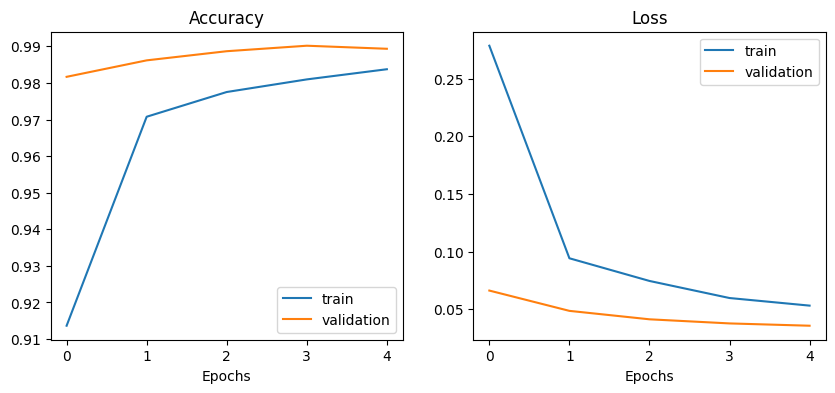

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

plt.show()

In [ ]:
sample = x_test[0:1]
sample

array([[[[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ]],

        [[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         

In [ ]:
prediction = model.predict(sample)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[1.2295441e-10, 5.1054331e-11, 2.8585217e-07, 8.5337001e-07,
        1.6210624e-13, 8.6417175e-12, 7.6242051e-17, 9.9999893e-01,
        9.2202196e-10, 4.2162991e-08]], dtype=float32)

In [ ]:
prediction = prediction.argmax()
prediction

np.int64(7)

In [ ]:
y_test[0]

np.uint8(7)

In [ ]:
model.save('mnist_cnn_model.keras')

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps

In [ ]:
model = load_model('mnist_cnn_model.keras')

Enter image path: /content/image.png


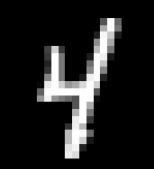

In [ ]:
image_path = input('Enter image path: ')
img = Image.open(image_path).convert('L')
img

In [ ]:
img = img.resize((28,28))
img

In [ ]:
img = ImageOps.invert(img)
img

In [ ]:
img_array = np.array(img)
img_array

array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 250, 240, 236, 247, 254, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 199,  91,  44, 164, 241, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 254, 134,  40,  25, 141, 237, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 236,  63,  22,  76, 205, 247, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 250, 170,  29,  30, 114, 246, 254, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 253, 233, 190, 192, 241, 255,
        255, 255, 255, 246, 111,  13,  48, 143, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 251, 201,  78,  75, 205, 255,
        255, 255, 254, 238,  75,   5,  78, 185, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 252, 213,  66,  38, 168, 255,
        255, 255, 247, 207,  29,   3, 127, 245, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 253, 228,  72,  37, 168, 255,
        255, 255, 228, 140,  18,  36, 159, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 252, 217,  67,  38, 168, 255,
        255, 255, 219, 113,  14,  85, 190, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 248, 161,  45,  40, 172, 255,
        255, 255, 185,  34,   3, 154, 231, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 242,  83,  17,  26, 110, 173,
        165, 143,  87,   2,  22, 199, 251, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 245, 201,  30,   0,   6,  32,  56,
         47,  29,  11,   6,  85, 225, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 223, 128,  12,  10,  23,  25,  26,
         34,  15,   0,  11, 167, 245, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 220, 124,  61, 105, 145, 161, 172,
        180,  73,   2,  30, 218, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 254, 252, 251, 253, 254, 254, 252,
        186,  66,  16,  96, 236, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 251,
        119,  32,  33, 140, 241, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 250,
         67,   5,  49, 189, 247, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 251, 226,
         45,  22, 100, 239, 253, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 227, 127,
         23,  19,  85, 204, 249, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 211,  61,
          9,   3,  59, 181, 246, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 210,  60,
          8,  41, 127, 244, 254, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 25

In [ ]:
img_array = img_array.astype('float32') / 255
img_array

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.    

In [ ]:
img_array = img_array.reshape(1,28,28,1)
img_array

array([[[[1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ]],

        [[1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         [1.        ],
         

In [ ]:
prediction = model.predict(img_array, verbose=0)
prediction

array([[1.0567991e-03, 3.3380780e-02, 5.2974927e-05, 9.8140781e-06,
        9.6241981e-01, 4.1332978e-06, 1.2144818e-04, 2.6901490e-03,
        4.3668671e-05, 2.2045811e-04]], dtype=float32)

In [ ]:
predicted_digit = np.argmax(prediction)
predicted_digit

np.int64(4)

In [ ]:
prob = np.max(prediction)
prob

np.float32(0.9624198)

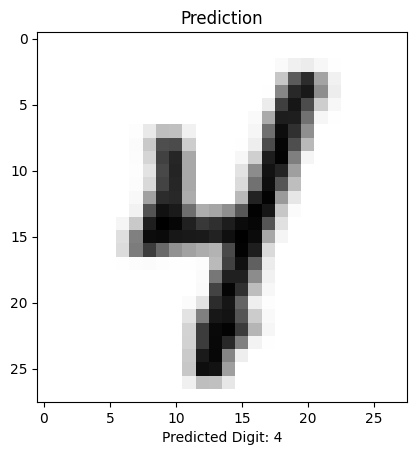

In [ ]:
plt.imshow(img, cmap='gray')
plt.xlabel(f'Predicted Digit: {predicted_digit}')
plt.title('Prediction')
plt.show()